Old ISF mice with both PRE and POST: 18


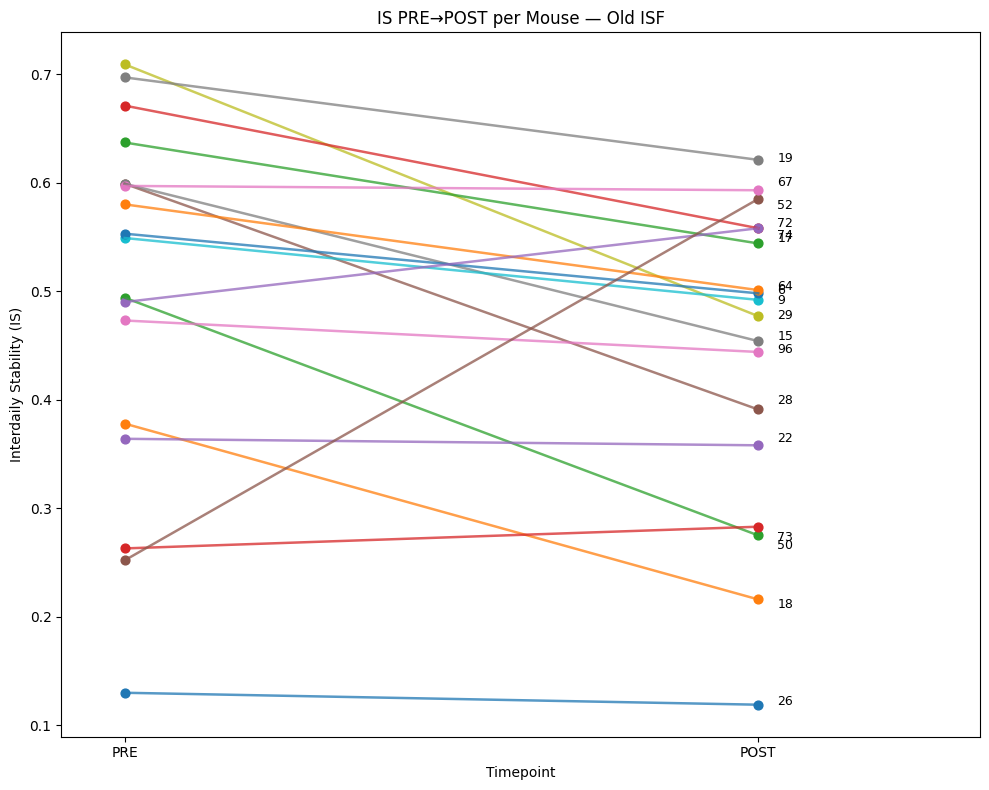

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- load circadian data ---
circ = pd.read_csv("Circadian_raw.csv")

# --- make column names safe (so PRE.POST becomes PRE_POST if needed) ---
def clean_colnames(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.replace(r"[^\w]+", "_", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df

circ = clean_colnames(circ)

# --- build subset: Old + ISF ---
# (circadian file uses Light_new like CTR/ISF and Age_new like Old/Mid/Young)
d = circ[["ID", "PRE_POST", "IS", "Age_new", "Light_new"]].dropna().copy()
d["ID"] = pd.to_numeric(d["ID"], errors="coerce")
d["Age_new"] = d["Age_new"].astype(str)
d["Light_new"] = d["Light_new"].astype(str)
d["PRE_POST"] = d["PRE_POST"].astype(str)

group = d[(d["Age_new"] == "Old") & (d["Light_new"] == "ISF")].copy()

# keep only mice with both PRE and POST
counts = group.groupby("ID")["PRE_POST"].nunique()
keep_ids = counts[counts == 2].index
group = group[group["ID"].isin(keep_ids)].copy()

# pivot to one row per mouse with PRE and POST
wide = group.pivot_table(index="ID", columns="PRE_POST", values="IS", aggfunc="mean")
wide = wide.dropna(subset=["PRE", "POST"]).reset_index()

print("Old ISF mice with both PRE and POST:", wide.shape[0])

# sort by POST to make labels cleaner
wide = wide.sort_values("POST").reset_index(drop=True)

# --- plot ---
fig, ax = plt.subplots(figsize=(10, 8))

# deterministic jitter so labels don’t perfectly overlap
rng = np.random.default_rng(0)
jitter = 0.01

for _, row in wide.iterrows():
    mouse_id = int(row["ID"])
    y_pre = float(row["PRE"])
    y_post = float(row["POST"])

    ax.plot([0, 1], [y_pre, y_post], linewidth=1.8, alpha=0.75)
    ax.scatter([0, 1], [y_pre, y_post], s=40)

    # label at POST
    ax.text(1.03, y_post + rng.uniform(-jitter, jitter), str(mouse_id),
            fontsize=9, va="center")

ax.set_xticks([0, 1], ["PRE", "POST"])
ax.set_xlim(-0.1, 1.35)
ax.set_title("IS PRE→POST per Mouse — Old ISF")
ax.set_xlabel("Timepoint")
ax.set_ylabel("Interdaily Stability (IS)")

plt.tight_layout()
plt.show()


Old CTR mice with both PRE and POST: 22


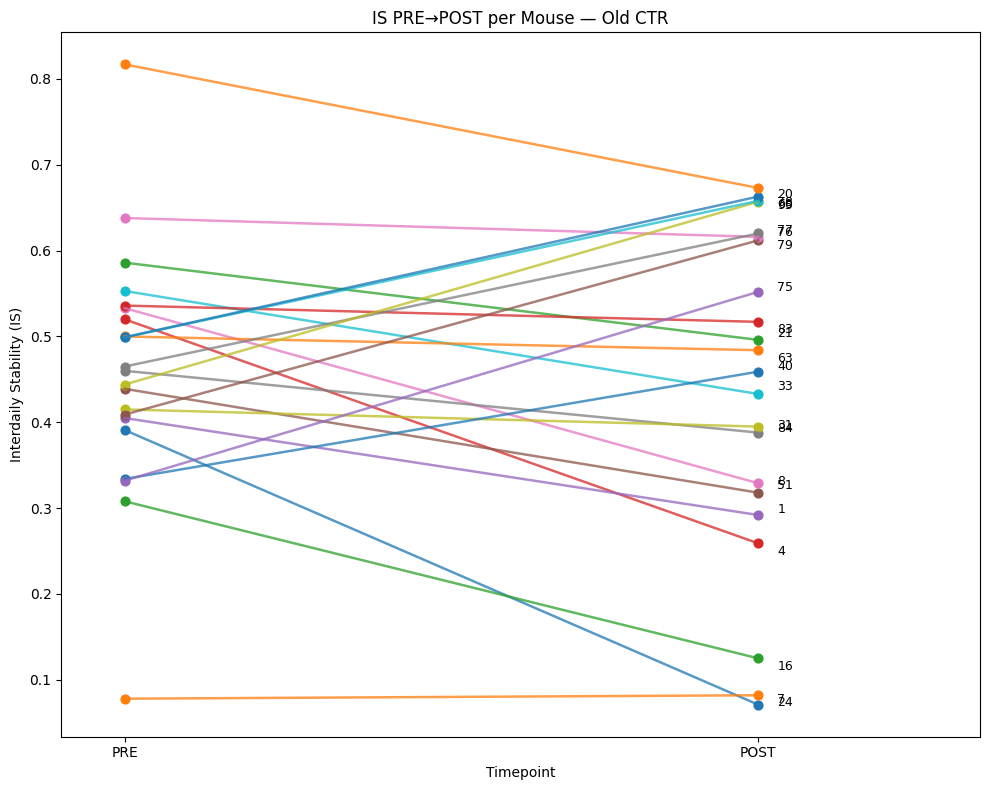

In [3]:
def clean_colnames(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.replace(r"[^\w]+", "_", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df

circ = clean_colnames(pd.read_csv("Circadian_raw.csv"))

d = circ[["ID", "PRE_POST", "IS", "Age_new", "Light_new"]].dropna().copy()
d["ID"] = pd.to_numeric(d["ID"], errors="coerce")
d["Age_new"] = d["Age_new"].astype(str)
d["Light_new"] = d["Light_new"].astype(str)
d["PRE_POST"] = d["PRE_POST"].astype(str)

group = d[(d["Age_new"] == "Old") & (d["Light_new"] == "CTR")].copy()

counts = group.groupby("ID")["PRE_POST"].nunique()
keep_ids = counts[counts == 2].index
group = group[group["ID"].isin(keep_ids)].copy()

wide = group.pivot_table(index="ID", columns="PRE_POST", values="IS", aggfunc="mean")
wide = wide.dropna(subset=["PRE", "POST"]).reset_index()

print("Old CTR mice with both PRE and POST:", wide.shape[0])

wide = wide.sort_values("POST").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 8))
rng = np.random.default_rng(0)
jitter = 0.01

for _, row in wide.iterrows():
    mouse_id = int(row["ID"])
    y_pre = float(row["PRE"])
    y_post = float(row["POST"])

    ax.plot([0, 1], [y_pre, y_post], linewidth=1.8, alpha=0.75)
    ax.scatter([0, 1], [y_pre, y_post], s=40)
    ax.text(1.03, y_post + rng.uniform(-jitter, jitter), str(mouse_id),
            fontsize=9, va="center")

ax.set_xticks([0, 1], ["PRE", "POST"])
ax.set_xlim(-0.1, 1.35)
ax.set_title("IS PRE→POST per Mouse — Old CTR")
ax.set_xlabel("Timepoint")
ax.set_ylabel("Interdaily Stability (IS)")

plt.tight_layout()
plt.show()

Mid ISF mice with both PRE and POST: 21


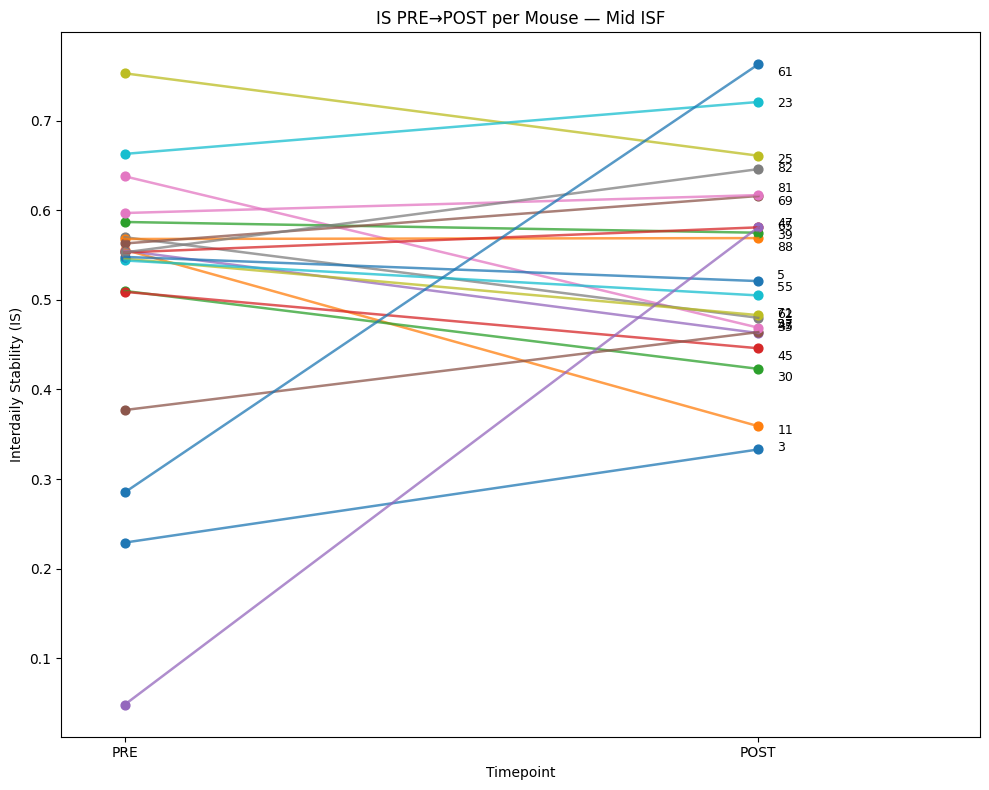

In [4]:
def clean_colnames(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.replace(r"[^\w]+", "_", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df

circ = clean_colnames(pd.read_csv("Circadian_raw.csv"))

d = circ[["ID", "PRE_POST", "IS", "Age_new", "Light_new"]].dropna().copy()
d["ID"] = pd.to_numeric(d["ID"], errors="coerce")
d["Age_new"] = d["Age_new"].astype(str)
d["Light_new"] = d["Light_new"].astype(str)
d["PRE_POST"] = d["PRE_POST"].astype(str)

group = d[(d["Age_new"] == "Mid") & (d["Light_new"] == "ISF")].copy()

counts = group.groupby("ID")["PRE_POST"].nunique()
keep_ids = counts[counts == 2].index
group = group[group["ID"].isin(keep_ids)].copy()

wide = group.pivot_table(index="ID", columns="PRE_POST", values="IS", aggfunc="mean")
wide = wide.dropna(subset=["PRE", "POST"]).reset_index()

print("Mid ISF mice with both PRE and POST:", wide.shape[0])

wide = wide.sort_values("POST").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 8))
rng = np.random.default_rng(0)
jitter = 0.01

for _, row in wide.iterrows():
    mouse_id = int(row["ID"])
    y_pre = float(row["PRE"])
    y_post = float(row["POST"])

    ax.plot([0, 1], [y_pre, y_post], linewidth=1.8, alpha=0.75)
    ax.scatter([0, 1], [y_pre, y_post], s=40)
    ax.text(1.03, y_post + rng.uniform(-jitter, jitter), str(mouse_id),
            fontsize=9, va="center")

ax.set_xticks([0, 1], ["PRE", "POST"])
ax.set_xlim(-0.1, 1.35)
ax.set_title("IS PRE→POST per Mouse — Mid ISF")
ax.set_xlabel("Timepoint")
ax.set_ylabel("Interdaily Stability (IS)")

plt.tight_layout()
plt.show()

Mid CTR mice with both PRE and POST: 22


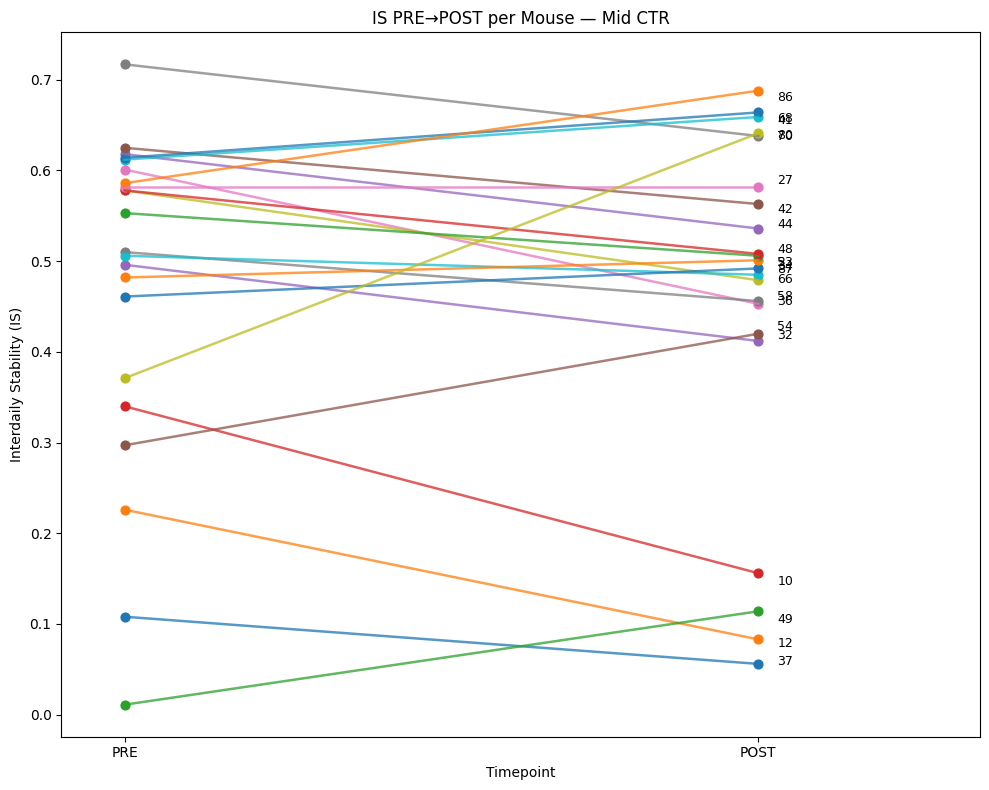

In [5]:
def clean_colnames(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.replace(r"[^\w]+", "_", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df

circ = clean_colnames(pd.read_csv("Circadian_raw.csv"))

d = circ[["ID", "PRE_POST", "IS", "Age_new", "Light_new"]].dropna().copy()
d["ID"] = pd.to_numeric(d["ID"], errors="coerce")
d["Age_new"] = d["Age_new"].astype(str)
d["Light_new"] = d["Light_new"].astype(str)
d["PRE_POST"] = d["PRE_POST"].astype(str)

group = d[(d["Age_new"] == "Mid") & (d["Light_new"] == "CTR")].copy()

counts = group.groupby("ID")["PRE_POST"].nunique()
keep_ids = counts[counts == 2].index
group = group[group["ID"].isin(keep_ids)].copy()

wide = group.pivot_table(index="ID", columns="PRE_POST", values="IS", aggfunc="mean")
wide = wide.dropna(subset=["PRE", "POST"]).reset_index()

print("Mid CTR mice with both PRE and POST:", wide.shape[0])

wide = wide.sort_values("POST").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 8))
rng = np.random.default_rng(0)
jitter = 0.01

for _, row in wide.iterrows():
    mouse_id = int(row["ID"])
    y_pre = float(row["PRE"])
    y_post = float(row["POST"])

    ax.plot([0, 1], [y_pre, y_post], linewidth=1.8, alpha=0.75)
    ax.scatter([0, 1], [y_pre, y_post], s=40)
    ax.text(1.03, y_post + rng.uniform(-jitter, jitter), str(mouse_id),
            fontsize=9, va="center")

ax.set_xticks([0, 1], ["PRE", "POST"])
ax.set_xlim(-0.1, 1.35)
ax.set_title("IS PRE→POST per Mouse — Mid CTR")
ax.set_xlabel("Timepoint")
ax.set_ylabel("Interdaily Stability (IS)")

plt.tight_layout()
plt.show()


Mid CTR mice with both PRE and POST: 22


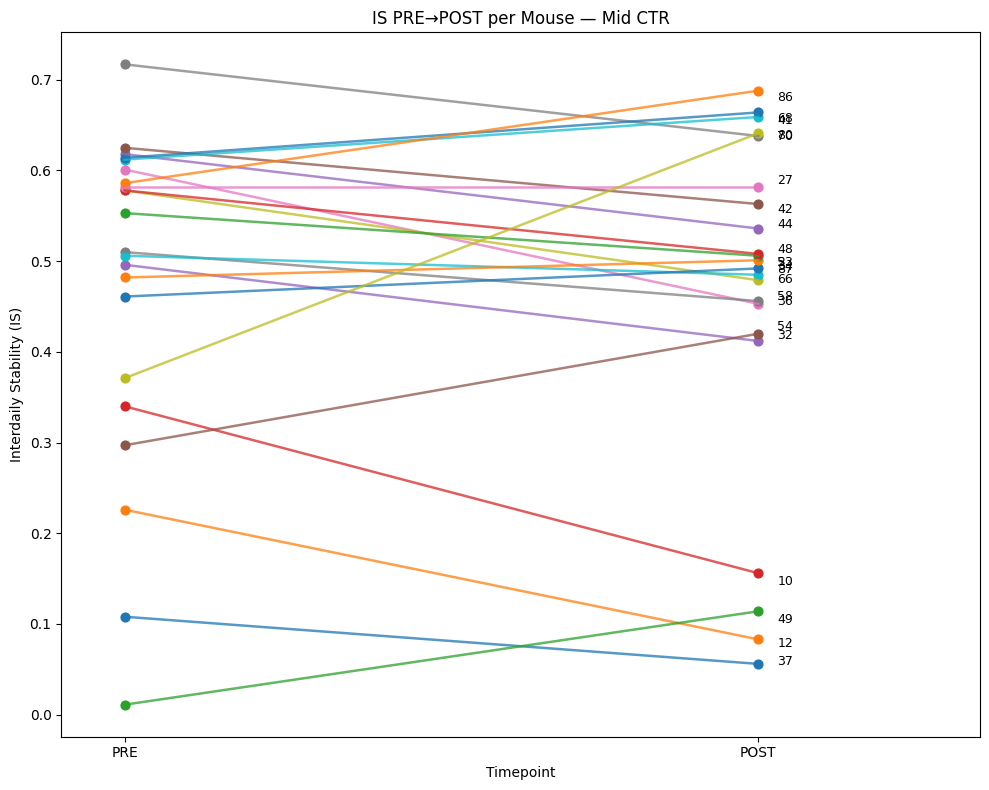

In [6]:
def clean_colnames(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.replace(r"[^\w]+", "_", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df

circ = clean_colnames(pd.read_csv("Circadian_raw.csv"))

d = circ[["ID", "PRE_POST", "IS", "Age_new", "Light_new"]].dropna().copy()
d["ID"] = pd.to_numeric(d["ID"], errors="coerce")
d["Age_new"] = d["Age_new"].astype(str)
d["Light_new"] = d["Light_new"].astype(str)
d["PRE_POST"] = d["PRE_POST"].astype(str)

group = d[(d["Age_new"] == "Mid") & (d["Light_new"] == "CTR")].copy()

counts = group.groupby("ID")["PRE_POST"].nunique()
keep_ids = counts[counts == 2].index
group = group[group["ID"].isin(keep_ids)].copy()

wide = group.pivot_table(index="ID", columns="PRE_POST", values="IS", aggfunc="mean")
wide = wide.dropna(subset=["PRE", "POST"]).reset_index()

print("Mid CTR mice with both PRE and POST:", wide.shape[0])

wide = wide.sort_values("POST").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 8))
rng = np.random.default_rng(0)
jitter = 0.01

for _, row in wide.iterrows():
    mouse_id = int(row["ID"])
    y_pre = float(row["PRE"])
    y_post = float(row["POST"])

    ax.plot([0, 1], [y_pre, y_post], linewidth=1.8, alpha=0.75)
    ax.scatter([0, 1], [y_pre, y_post], s=40)
    ax.text(1.03, y_post + rng.uniform(-jitter, jitter), str(mouse_id),
            fontsize=9, va="center")

ax.set_xticks([0, 1], ["PRE", "POST"])
ax.set_xlim(-0.1, 1.35)
ax.set_title("IS PRE→POST per Mouse — Mid CTR")
ax.set_xlabel("Timepoint")
ax.set_ylabel("Interdaily Stability (IS)")

plt.tight_layout()
plt.show()


Young CTR mice with both PRE and POST: 5


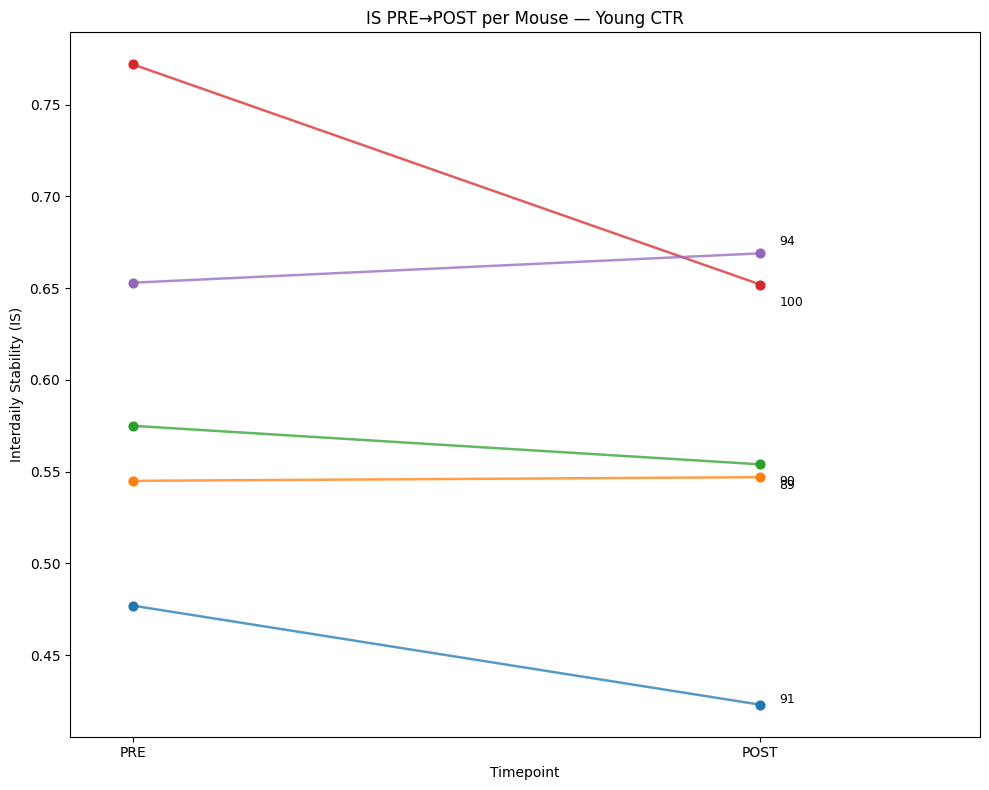

In [7]:
def clean_colnames(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.replace(r"[^\w]+", "_", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df

circ = clean_colnames(pd.read_csv("Circadian_raw.csv"))

d = circ[["ID", "PRE_POST", "IS", "Age_new", "Light_new"]].dropna().copy()
d["ID"] = pd.to_numeric(d["ID"], errors="coerce")
d["Age_new"] = d["Age_new"].astype(str)
d["Light_new"] = d["Light_new"].astype(str)
d["PRE_POST"] = d["PRE_POST"].astype(str)

group = d[(d["Age_new"] == "Young") & (d["Light_new"] == "CTR")].copy()

counts = group.groupby("ID")["PRE_POST"].nunique()
keep_ids = counts[counts == 2].index
group = group[group["ID"].isin(keep_ids)].copy()

wide = group.pivot_table(index="ID", columns="PRE_POST", values="IS", aggfunc="mean")
wide = wide.dropna(subset=["PRE", "POST"]).reset_index()

print("Young CTR mice with both PRE and POST:", wide.shape[0])

wide = wide.sort_values("POST").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 8))
rng = np.random.default_rng(0)
jitter = 0.01

for _, row in wide.iterrows():
    mouse_id = int(row["ID"])
    y_pre = float(row["PRE"])
    y_post = float(row["POST"])

    ax.plot([0, 1], [y_pre, y_post], linewidth=1.8, alpha=0.75)
    ax.scatter([0, 1], [y_pre, y_post], s=40)
    ax.text(1.03, y_post + rng.uniform(-jitter, jitter), str(mouse_id),
            fontsize=9, va="center")

ax.set_xticks([0, 1], ["PRE", "POST"])
ax.set_xlim(-0.1, 1.35)
ax.set_title("IS PRE→POST per Mouse — Young CTR")
ax.set_xlabel("Timepoint")
ax.set_ylabel("Interdaily Stability (IS)")

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="talk")

def clean_colnames(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.replace(r"[^\w]+", "_", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df

# Load
circ = clean_colnames(pd.read_csv("Circadian_raw.csv"))
barnes = clean_colnames(pd.read_csv("Barnes_clean.csv"))
nor = clean_colnames(pd.read_csv("UCBAge_Novel_clean.csv"))

# Harmonise IDs
if "Animal_ID" in nor.columns and "ID" not in nor.columns:
    nor = nor.rename(columns={"Animal_ID": "ID"})

for df in (circ, barnes, nor):
    df["ID"] = pd.to_numeric(df["ID"], errors="coerce").astype("Int64")

barnes["Trial"] = pd.to_numeric(barnes["Trial"], errors="coerce")

# Barnes Trial 6 percent correct
TRIAL_END = 6
barnes_t6 = barnes[barnes["Trial"] == TRIAL_END].copy()
barnes_t6["Goal_Box_feq_new"] = pd.to_numeric(barnes_t6["Goal_Box_feq_new"], errors="coerce")
barnes_t6["Hole_errors"] = pd.to_numeric(barnes_t6["Hole_errors"], errors="coerce")

barnes_t6 = barnes_t6.dropna(subset=["ID","Light_new","Age_new","Sex_new","Goal_Box_feq_new","Hole_errors"]).copy()
barnes_t6 = barnes_t6[(barnes_t6["Goal_Box_feq_new"] >= 0) & (barnes_t6["Hole_errors"] >= 0)].copy()
barnes_t6["total_entries"] = barnes_t6["Goal_Box_feq_new"] + barnes_t6["Hole_errors"]
barnes_t6 = barnes_t6[barnes_t6["total_entries"] > 0].copy()
barnes_t6["p_correct"] = barnes_t6["Goal_Box_feq_new"] / barnes_t6["total_entries"]

# Circadian delta_IS = POST - PRE
wide_IS = circ.pivot_table(index="ID", columns="PRE_POST", values="IS", aggfunc="mean")
delta_IS = (wide_IS.get("POST") - wide_IS.get("PRE")).rename("delta_IS").reset_index()
IS_pre = wide_IS.get("PRE").rename("IS_pre").reset_index()

barnes_t6 = barnes_t6.merge(delta_IS, on="ID", how="left").merge(IS_pre, on="ID", how="left")

# NOR DI
if "N_obj_nose_duration_s" in nor.columns and "F_obj_nose_duration_s" in nor.columns:
    N = pd.to_numeric(nor["N_obj_nose_duration_s"], errors="coerce")
    F = pd.to_numeric(nor["F_obj_nose_duration_s"], errors="coerce")
    nor_m = nor[(N.notna()) & (F.notna())].copy()
    N = N.loc[nor_m.index]; F = F.loc[nor_m.index]
    nor_m["DI_duration"] = (N - F) / (N + F + 1e-9)
else:
    nor_m = nor.copy()

print("Circadian mice:", circ["ID"].nunique())
print("Barnes Trial 6 mice:", barnes_t6["ID"].nunique())
print("NOR mice:", nor_m["ID"].nunique())


Circadian mice: 94
Barnes Trial 6 mice: 88
NOR mice: 79


Difference-in-differences style: plot PRE→POST change per mouse, faceted by group (ISF vs CTR).
This makes it visually obvious whether ISF shifts differently than CTR.

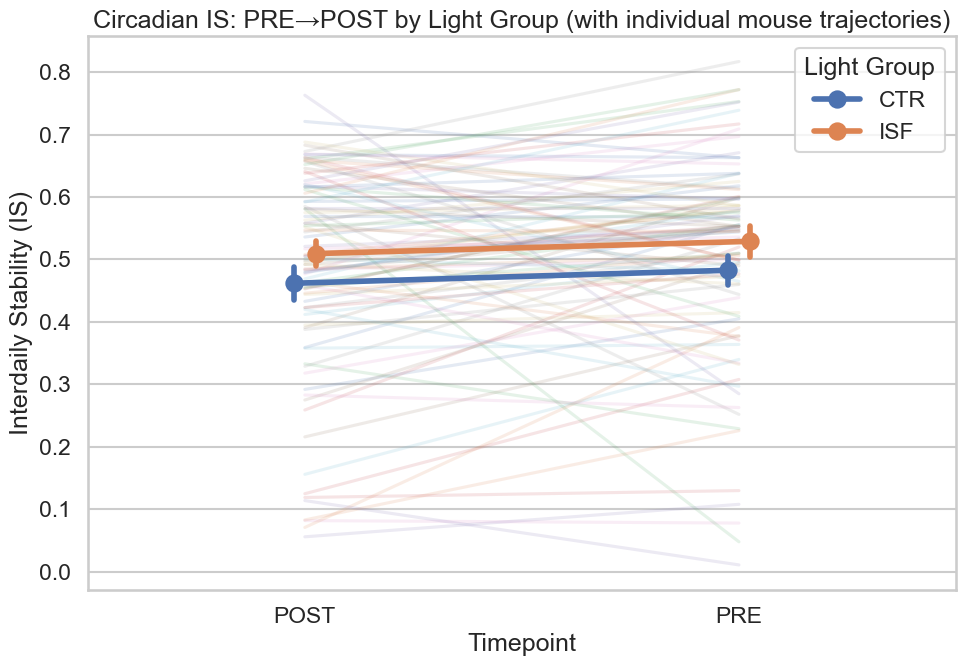

In [9]:
# IS PRE→POST trajectories, all mice, coloured by light group (CTR vs ISF)
d = circ[["ID","PRE_POST","IS","Light_new"]].dropna().copy()
d["PRE_POST"] = d["PRE_POST"].astype(str)
d["Light_new"] = d["Light_new"].astype(str)

# Keep mice with both timepoints
counts = d.groupby("ID")["PRE_POST"].nunique()
keep_ids = counts[counts == 2].index
d = d[d["ID"].isin(keep_ids)].copy()

fig, ax = plt.subplots(figsize=(10, 7))

# Plot per-mouse lines faintly
for mid in d["ID"].unique():
    dm = d[d["ID"] == mid].sort_values("PRE_POST")
    if dm.shape[0] == 2:
        ax.plot(dm["PRE_POST"], dm["IS"], alpha=0.15)

# Overlay group mean ± SE
sns.pointplot(data=d, x="PRE_POST", y="IS", hue="Light_new", errorbar="se", dodge=True, ax=ax)

ax.set_title("Circadian IS: PRE→POST by Light Group (with individual mouse trajectories)")
ax.set_xlabel("Timepoint")
ax.set_ylabel("Interdaily Stability (IS)")
ax.legend(title="Light Group")
plt.tight_layout()
plt.show()


none of these show a clear separation.

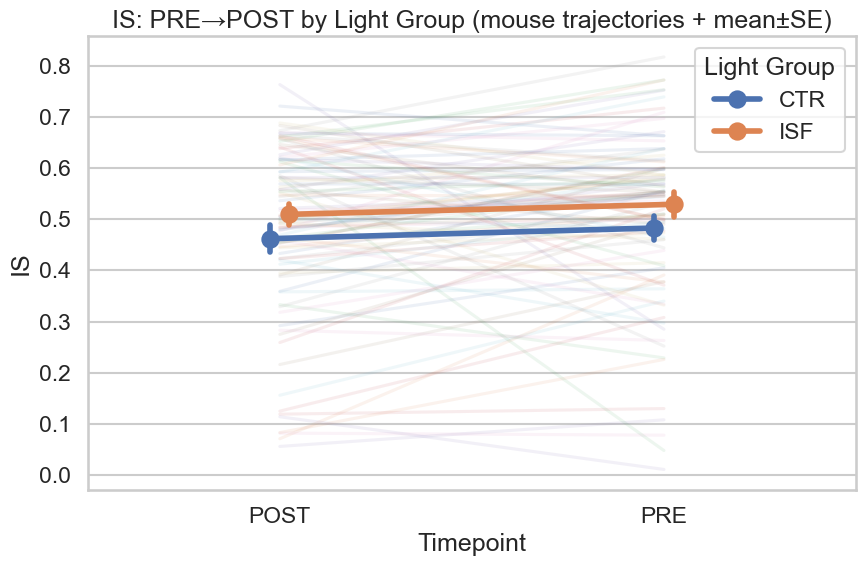

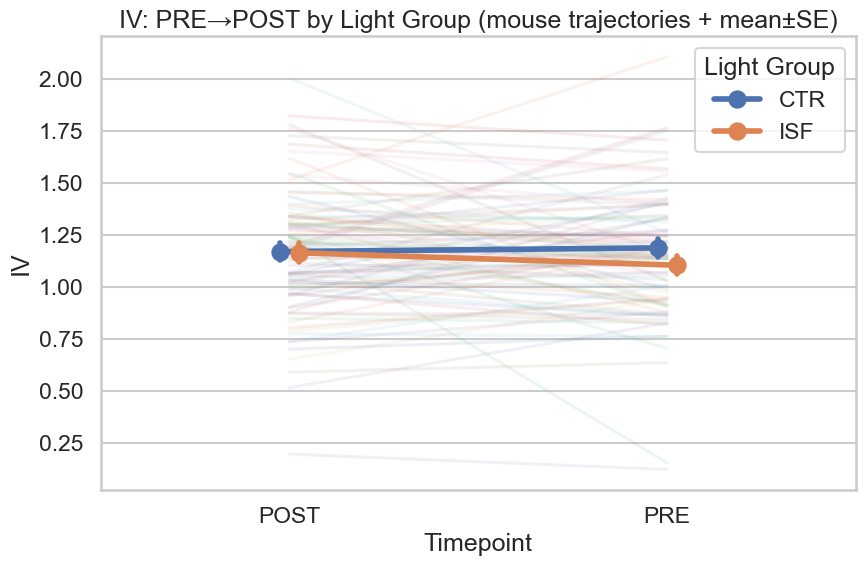

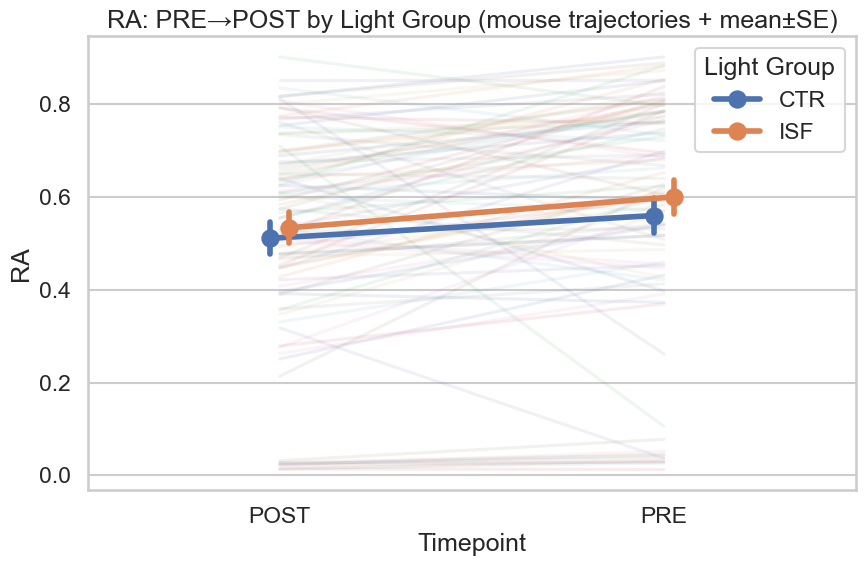

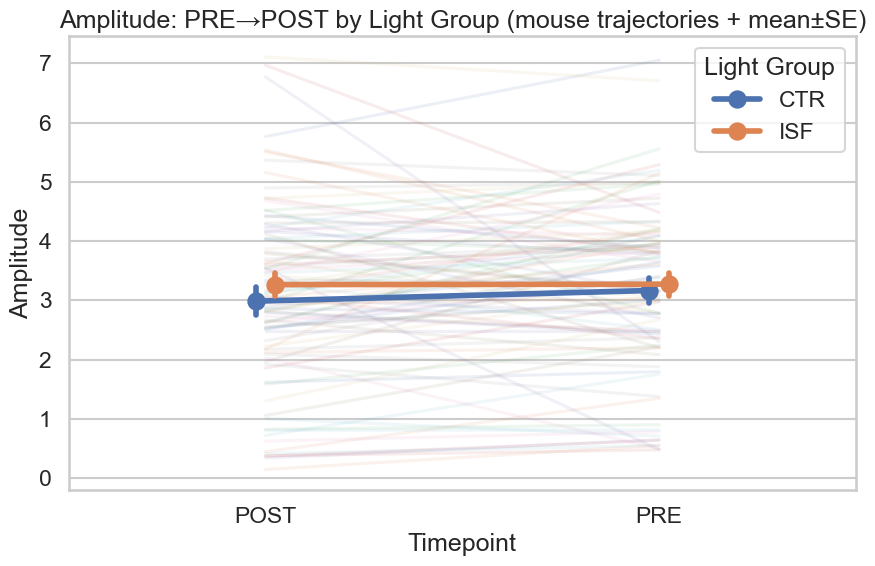

In [10]:
metrics = ["IS", "IV", "RA", "Amplitude"]

for metric in metrics:
    if metric not in circ.columns:
        continue
    d = circ[["ID","PRE_POST",metric,"Light_new"]].dropna().copy()
    d["PRE_POST"] = d["PRE_POST"].astype(str)
    d["Light_new"] = d["Light_new"].astype(str)

    counts = d.groupby("ID")["PRE_POST"].nunique()
    keep_ids = counts[counts == 2].index
    d = d[d["ID"].isin(keep_ids)].copy()

    fig, ax = plt.subplots(figsize=(9, 6))

    for mid in d["ID"].unique():
        dm = d[d["ID"] == mid].sort_values("PRE_POST")
        if dm.shape[0] == 2:
            ax.plot(dm["PRE_POST"], dm[metric], alpha=0.10)

    sns.pointplot(data=d, x="PRE_POST", y=metric, hue="Light_new", errorbar="se", dodge=True, ax=ax)

    ax.set_title(f"{metric}: PRE→POST by Light Group (mouse trajectories + mean±SE)")
    ax.set_xlabel("Timepoint")
    ax.set_ylabel(metric)
    ax.legend(title="Light Group")
    plt.tight_layout()
    plt.show()


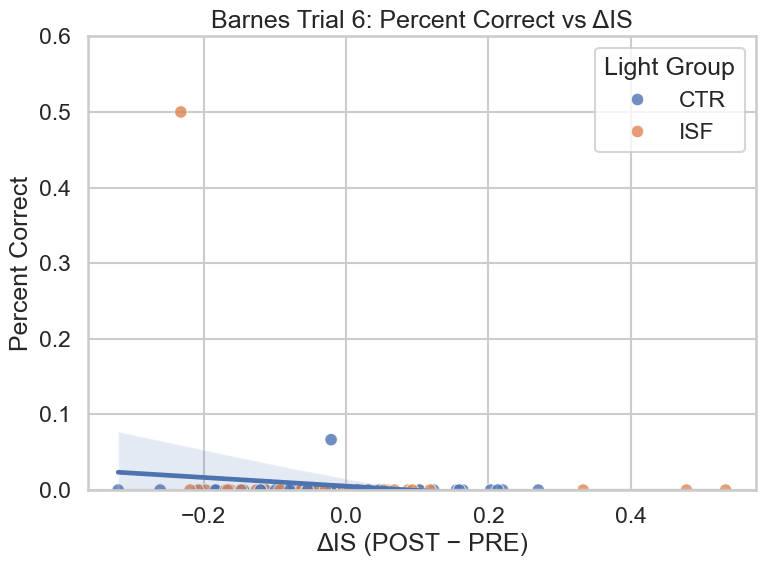

In [19]:
d = barnes_t6.dropna(subset=["delta_IS","p_correct"]).copy()
d["Light_new"] = d["Light_new"].astype(str)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=d, x="delta_IS", y="p_correct", hue="Light_new", alpha=0.8, ax=ax)
sns.regplot(data=d, x="delta_IS", y="p_correct", scatter=False, ax=ax)

ax.set_title("Barnes Trial 6: Percent Correct vs ΔIS")
ax.set_xlabel("ΔIS (POST − PRE)")
ax.set_ylabel("Percent Correct")
ax.set_ylim(0, 0.6)
ax.legend(title="Light Group")
plt.tight_layout()
plt.show()


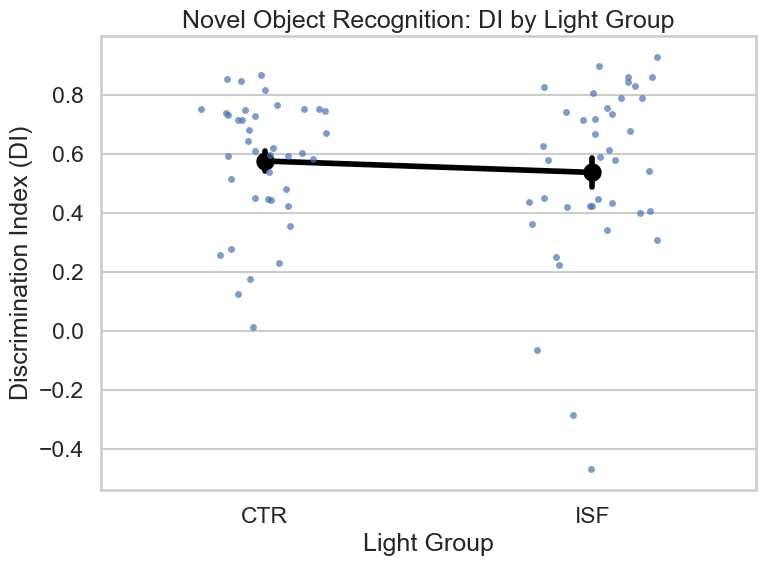

In [14]:
d = nor_m.dropna(subset=["DI_duration","Light_new"]).copy()
d["Light_new"] = d["Light_new"].astype(str)

fig, ax = plt.subplots(figsize=(8, 6))
sns.stripplot(data=d, x="Light_new", y="DI_duration", jitter=0.2, alpha=0.7, ax=ax)
sns.pointplot(data=d, x="Light_new", y="DI_duration", errorbar="se", color="black", ax=ax)

ax.set_title("Novel Object Recognition: DI by Light Group")
ax.set_xlabel("Light Group")
ax.set_ylabel("Discrimination Index (DI)")
plt.tight_layout()
plt.show()


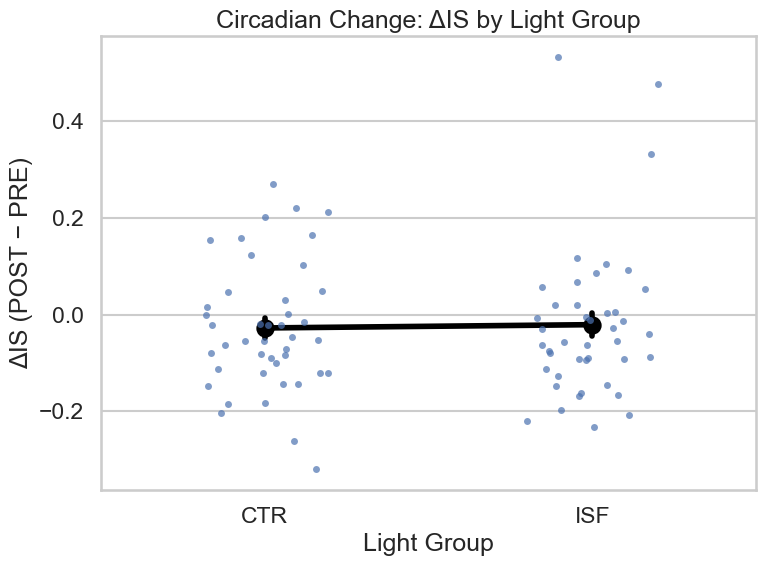

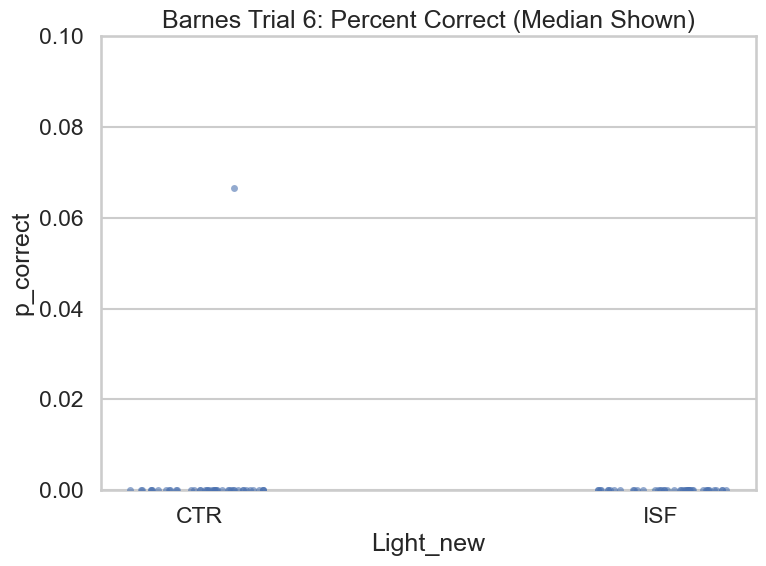

In [21]:
# Plot delta_IS by Light group (does light change circadian change?)
d1 = barnes_t6.dropna(subset=["delta_IS","Light_new"]).copy()
d1["Light_new"] = d1["Light_new"].astype(str)

fig, ax = plt.subplots(figsize=(8, 6))
sns.stripplot(data=d1, x="Light_new", y="delta_IS", jitter=0.2, alpha=0.7, ax=ax)
sns.pointplot(data=d1, x="Light_new", y="delta_IS", errorbar="se", color="black", ax=ax)
ax.set_title("Circadian Change: ΔIS by Light Group")
ax.set_xlabel("Light Group")
ax.set_ylabel("ΔIS (POST − PRE)")
plt.tight_layout()
plt.show()

# Plot p_correct by Light group again (direct effect visual)
d = barnes_t6.copy()
d["Light_new"] = d["Light_new"].astype(str)

fig, ax = plt.subplots(figsize=(8,6))

sns.stripplot(data=d, x="Light_new", y="p_correct", jitter=0.15, alpha=0.6, ax=ax)

# Plot median only (NOT mean)
medians = d.groupby("Light_new")["p_correct"].median()
for i, group in enumerate(medians.index):
    ax.scatter(i, medians[group], s=200, marker="_")

ax.set_title("Barnes Trial 6: Percent Correct (Median Shown)")
ax.set_ylim(0, 0.1)
plt.tight_layout()
plt.show()



In [26]:
d = barnes[barnes["Trial"] == 6].copy()

d["EntryZone_freq_new"] = pd.to_numeric(d["EntryZone_freq_new"], errors="coerce")
d["Hole_errors"] = pd.to_numeric(d["Hole_errors"], errors="coerce")

d = d.dropna(subset=["EntryZone_freq_new","Hole_errors"]).copy()
d["total_pokes"] = d["EntryZone_freq_new"] + d["Hole_errors"]

d = d[d["total_pokes"] > 0]
d["probe_accuracy"] = d["EntryZone_freq_new"] / d["total_pokes"]

print(d["probe_accuracy"].describe())


count    88.000000
mean      0.159607
std       0.131270
min       0.000000
25%       0.065625
50%       0.149074
75%       0.211466
max       0.666667
Name: probe_accuracy, dtype: float64


In [27]:
d = barnes[barnes["Trial"] == 6].copy()
print(d[["Q1","Q2","Q3","Q4"]].describe())


              Q1         Q2         Q3         Q4
count  89.000000  89.000000  89.000000  89.000000
mean   22.400954  19.631935  22.793256  37.912722
std    10.821790   7.904214   8.743096  11.166653
min     0.000000   5.253940   9.230000  14.200000
25%    15.397600  13.485100  16.462300  29.485700
50%    22.300000  19.813000  22.238500  37.258900
75%    28.287600  24.693500  27.136500  44.213400
max    62.199900  46.000000  55.604200  68.900000


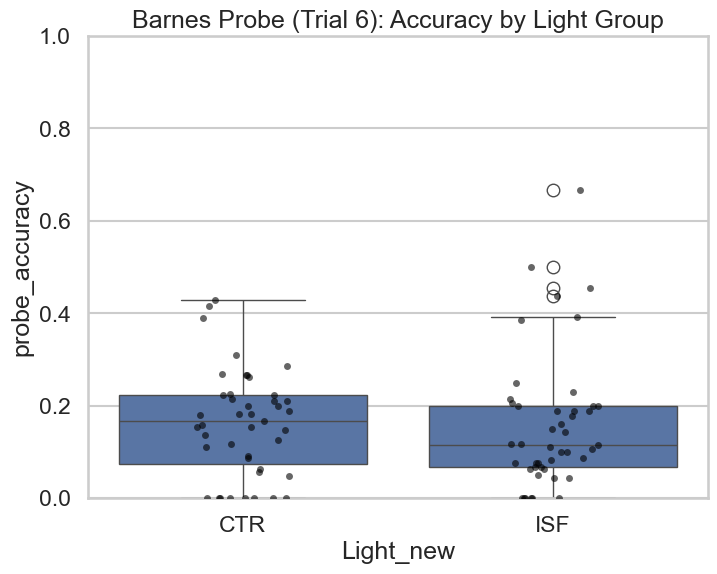

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

d = barnes[barnes["Trial"] == 6].copy()
d["EntryZone_freq_new"] = pd.to_numeric(d["EntryZone_freq_new"], errors="coerce")
d["Hole_errors"] = pd.to_numeric(d["Hole_errors"], errors="coerce")
d["total"] = d["EntryZone_freq_new"] + d["Hole_errors"]
d = d[d["total"] > 0]
d["probe_accuracy"] = d["EntryZone_freq_new"] / d["total"]
d["Light_new"] = d["Light_new"].astype(str)

fig, ax = plt.subplots(figsize=(8,6))
sns.boxplot(data=d, x="Light_new", y="probe_accuracy", ax=ax)
sns.stripplot(data=d, x="Light_new", y="probe_accuracy", color="black", alpha=0.6, jitter=0.15, ax=ax)

ax.set_title("Barnes Probe (Trial 6): Accuracy by Light Group")
ax.set_ylim(0, 1)
plt.show()


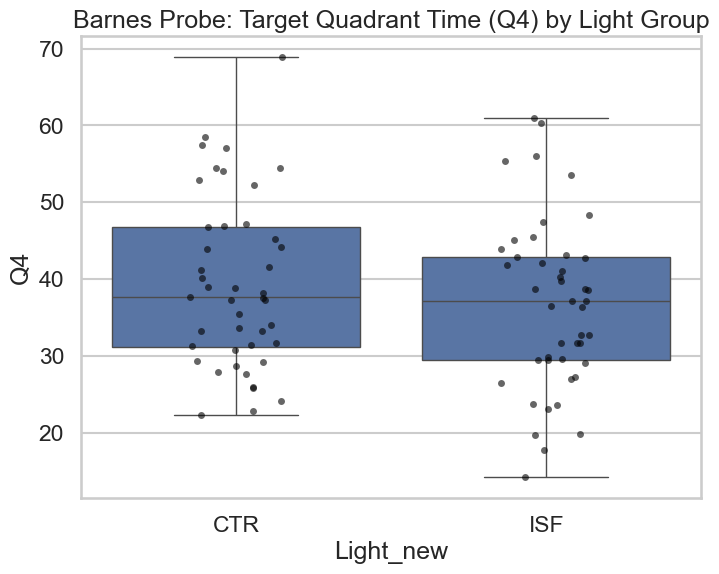

In [29]:
d = barnes[barnes["Trial"] == 6].copy()
d["Light_new"] = d["Light_new"].astype(str)

fig, ax = plt.subplots(figsize=(8,6))
sns.boxplot(data=d, x="Light_new", y="Q4", ax=ax)
sns.stripplot(data=d, x="Light_new", y="Q4", color="black", alpha=0.6, jitter=0.15, ax=ax)

ax.set_title("Barnes Probe: Target Quadrant Time (Q4) by Light Group")
plt.show()


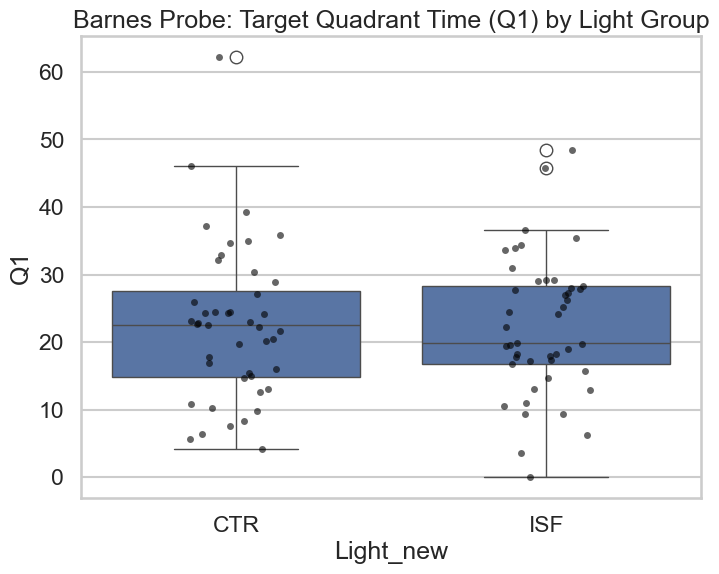

In [40]:
d = barnes[barnes["Trial"] == 6].copy()
d["Light_new"] = d["Light_new"].astype(str)

fig, ax = plt.subplots(figsize=(8,6))
sns.boxplot(data=d, x="Light_new", y="Q1", ax=ax)
sns.stripplot(data=d, x="Light_new", y="Q1", color="black", alpha=0.6, jitter=0.15, ax=ax)

ax.set_title("Barnes Probe: Target Quadrant Time (Q1) by Light Group")
plt.show()


In [30]:
import scipy.stats as stats

d = barnes[barnes["Trial"] == 6].copy()
d["EntryZone_freq_new"] = pd.to_numeric(d["EntryZone_freq_new"], errors="coerce")
d["Hole_errors"] = pd.to_numeric(d["Hole_errors"], errors="coerce")
d["total"] = d["EntryZone_freq_new"] + d["Hole_errors"]
d = d[d["total"] > 0]
d["probe_accuracy"] = d["EntryZone_freq_new"] / d["total"]

ctr = d[d["Light_new"]=="CTR"]["probe_accuracy"]
isf = d[d["Light_new"]=="ISF"]["probe_accuracy"]

print("Mann-Whitney U test:", stats.mannwhitneyu(ctr, isf))


Mann-Whitney U test: MannwhitneyuResult(statistic=np.float64(1077.5), pvalue=np.float64(0.3596294275418628))


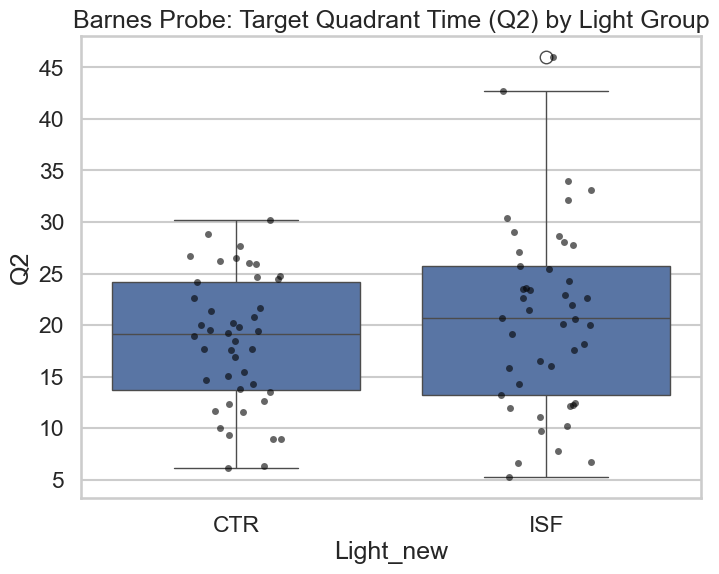

In [41]:
d = barnes[barnes["Trial"] == 6].copy()
d["Light_new"] = d["Light_new"].astype(str)

fig, ax = plt.subplots(figsize=(8,6))
sns.boxplot(data=d, x="Light_new", y="Q2", ax=ax)
sns.stripplot(data=d, x="Light_new", y="Q2", color="black", alpha=0.6, jitter=0.15, ax=ax)

ax.set_title("Barnes Probe: Target Quadrant Time (Q2) by Light Group")
plt.show()


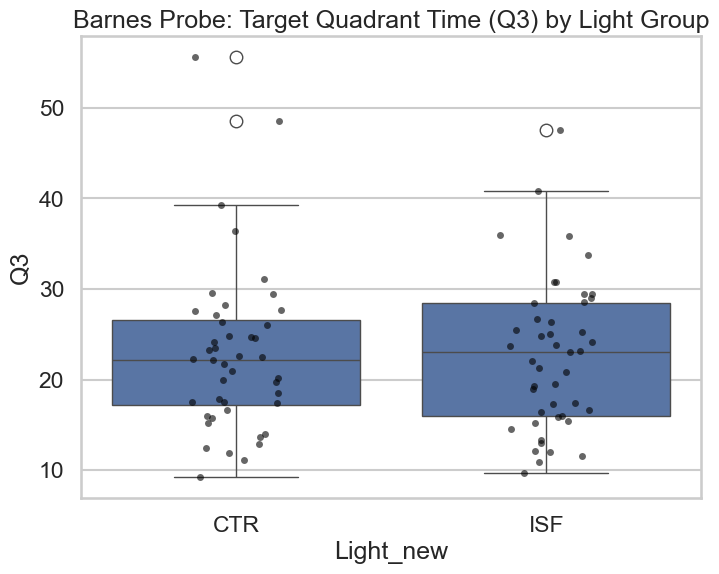

In [42]:
d = barnes[barnes["Trial"] == 6].copy()
d["Light_new"] = d["Light_new"].astype(str)

fig, ax = plt.subplots(figsize=(8,6))
sns.boxplot(data=d, x="Light_new", y="Q3", ax=ax)
sns.stripplot(data=d, x="Light_new", y="Q3", color="black", alpha=0.6, jitter=0.15, ax=ax)

ax.set_title("Barnes Probe: Target Quadrant Time (Q3) by Light Group")
plt.show()


test whether age shows anything

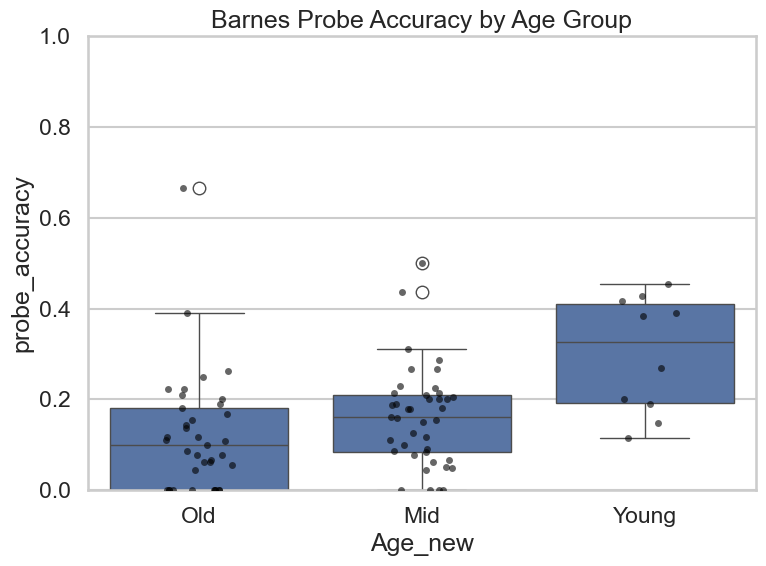

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", context="talk")

d = barnes[barnes["Trial"] == 6].copy()
d["EntryZone_freq_new"] = pd.to_numeric(d["EntryZone_freq_new"], errors="coerce")
d["Hole_errors"] = pd.to_numeric(d["Hole_errors"], errors="coerce")

d["total"] = d["EntryZone_freq_new"] + d["Hole_errors"]
d = d[d["total"] > 0].copy()

d["probe_accuracy"] = d["EntryZone_freq_new"] / d["total"]
d["Age_new"] = d["Age_new"].astype(str)

fig, ax = plt.subplots(figsize=(8,6))
sns.boxplot(data=d, x="Age_new", y="probe_accuracy", ax=ax)
sns.stripplot(data=d, x="Age_new", y="probe_accuracy", color="black", alpha=0.6, jitter=0.15, ax=ax)

ax.set_title("Barnes Probe Accuracy by Age Group")
ax.set_ylim(0,1)
plt.tight_layout()
plt.show()


In [32]:
import scipy.stats as stats

groups = []
for age in d["Age_new"].unique():
    groups.append(d[d["Age_new"] == age]["probe_accuracy"])

print("Kruskal–Wallis test:")
print(stats.kruskal(*groups))


Kruskal–Wallis test:
KruskalResult(statistic=np.float64(14.347783088550642), pvalue=np.float64(0.0007663346955639882))


In [33]:
ages = d["Age_new"].unique()

for i in range(len(ages)):
    for j in range(i+1, len(ages)):
        a = d[d["Age_new"] == ages[i]]["probe_accuracy"]
        b = d[d["Age_new"] == ages[j]]["probe_accuracy"]
        print(f"{ages[i]} vs {ages[j]}:",
              stats.mannwhitneyu(a, b))


Old vs Mid: MannwhitneyuResult(statistic=np.float64(554.5), pvalue=np.float64(0.04108760132034301))
Old vs Young: MannwhitneyuResult(statistic=np.float64(52.0), pvalue=np.float64(0.0005375204475271147))
Mid vs Young: MannwhitneyuResult(statistic=np.float64(92.0), pvalue=np.float64(0.007576185873506009))


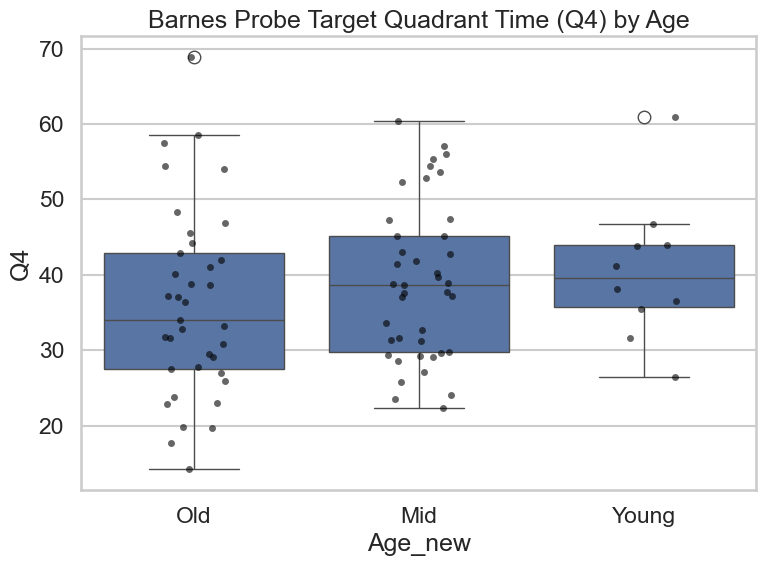

Kruskal–Wallis Q4:
KruskalResult(statistic=np.float64(2.237786337641384), pvalue=np.float64(0.3266411312053155))


In [34]:
fig, ax = plt.subplots(figsize=(8,6))
sns.boxplot(data=d, x="Age_new", y="Q4", ax=ax)
sns.stripplot(data=d, x="Age_new", y="Q4", color="black", alpha=0.6, jitter=0.15, ax=ax)

ax.set_title("Barnes Probe Target Quadrant Time (Q4) by Age")
plt.tight_layout()
plt.show()

print("Kruskal–Wallis Q4:")
groups_q4 = [d[d["Age_new"] == age]["Q4"] for age in d["Age_new"].unique()]
print(stats.kruskal(*groups_q4))


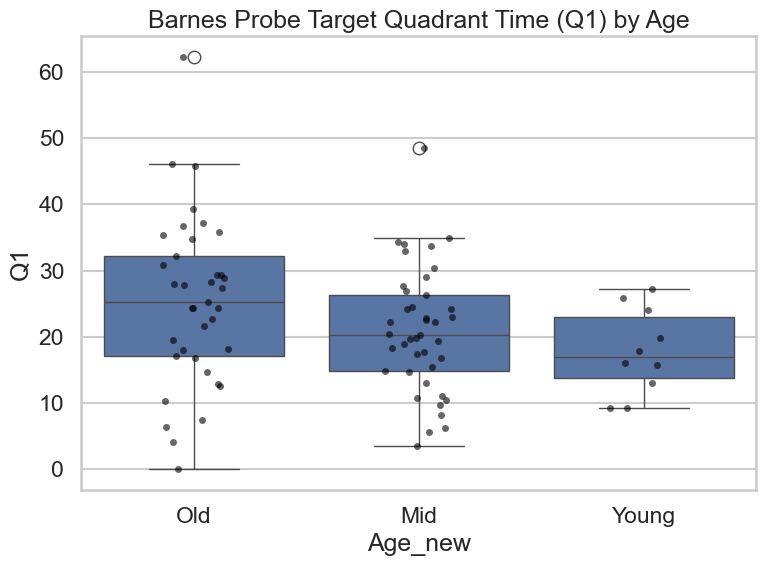

Kruskal–Wallis Q1:
KruskalResult(statistic=np.float64(5.600759687395532), pvalue=np.float64(0.06078696869248909))


In [36]:
fig, ax = plt.subplots(figsize=(8,6))
sns.boxplot(data=d, x="Age_new", y="Q1", ax=ax)
sns.stripplot(data=d, x="Age_new", y="Q1", color="black", alpha=0.6, jitter=0.15, ax=ax)

ax.set_title("Barnes Probe Target Quadrant Time (Q1) by Age")
plt.tight_layout()
plt.show()

print("Kruskal–Wallis Q1:")
groups_q1 = [d[d["Age_new"] == age]["Q1"] for age in d["Age_new"].unique()]
print(stats.kruskal(*groups_q1))


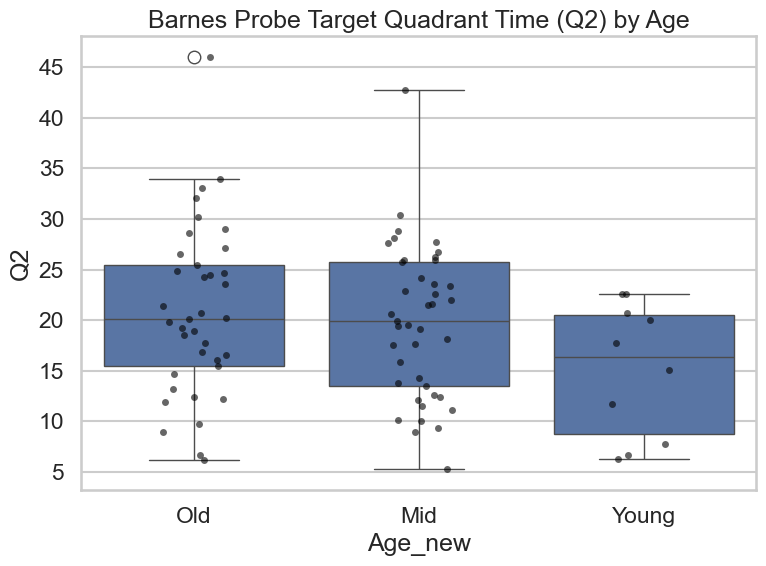

Kruskal–Wallis Q2:
KruskalResult(statistic=np.float64(3.7720715729671537), pvalue=np.float64(0.1516718783589263))


In [37]:
fig, ax = plt.subplots(figsize=(8,6))
sns.boxplot(data=d, x="Age_new", y="Q2", ax=ax)
sns.stripplot(data=d, x="Age_new", y="Q2", color="black", alpha=0.6, jitter=0.15, ax=ax)

ax.set_title("Barnes Probe Target Quadrant Time (Q2) by Age")
plt.tight_layout()
plt.show()

print("Kruskal–Wallis Q2:")
groups_q2 = [d[d["Age_new"] == age]["Q2"] for age in d["Age_new"].unique()]
print(stats.kruskal(*groups_q2))


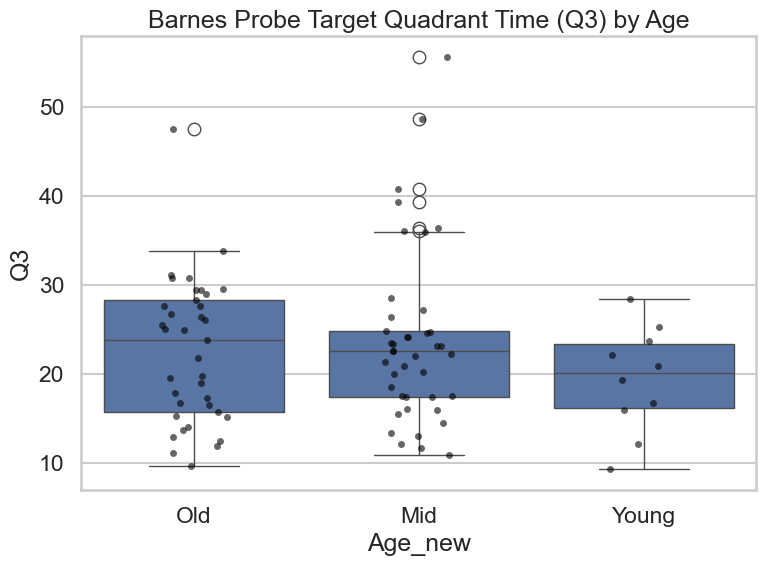

Kruskal–Wallis Q3:
KruskalResult(statistic=np.float64(1.386298081688196), pvalue=np.float64(0.49999906985878884))


In [38]:
fig, ax = plt.subplots(figsize=(8,6))
sns.boxplot(data=d, x="Age_new", y="Q3", ax=ax)
sns.stripplot(data=d, x="Age_new", y="Q3", color="black", alpha=0.6, jitter=0.15, ax=ax)

ax.set_title("Barnes Probe Target Quadrant Time (Q3) by Age")
plt.tight_layout()
plt.show()

print("Kruskal–Wallis Q3:")
groups_q3 = [d[d["Age_new"] == age]["Q3"] for age in d["Age_new"].unique()]
print(stats.kruskal(*groups_q3))


In [44]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Build probe accuracy again
d = barnes[barnes["Trial"] == 6].copy()
d["EntryZone_freq_new"] = pd.to_numeric(d["EntryZone_freq_new"], errors="coerce")
d["Hole_errors"] = pd.to_numeric(d["Hole_errors"], errors="coerce")

d["total"] = d["EntryZone_freq_new"] + d["Hole_errors"]
d = d[d["total"] > 0].copy()
d["probe_accuracy"] = d["EntryZone_freq_new"] / d["total"]

# Merge circadian POST values (more relevant than delta here)
circ_post = circ[circ["PRE_POST"] == "POST"][["ID","IS","IV","RA","Amplitude"]].copy()

d = d.merge(circ_post, on="ID", how="left")

# Keep only OLD animals
d_old = d[d["Age_new"] == "Old"].copy()

print("Old animals:", d_old.shape[0])


Old animals: 37


In [45]:
model = smf.ols(
    "probe_accuracy ~ IS",
    data=d_old
).fit(cov_type="HC3")

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:         probe_accuracy   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.022
Method:                 Least Squares   F-statistic:                    0.3553
Date:                Tue, 17 Feb 2026   Prob (F-statistic):              0.555
Time:                        21:00:30   Log-Likelihood:                 23.083
No. Observations:                  37   AIC:                            -42.17
Df Residuals:                      35   BIC:                            -38.94
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1487      0.052      2.869      0.0

In [46]:
for metric in ["IV","RA","Amplitude"]:
    m = smf.ols(
        f"probe_accuracy ~ {metric}",
        data=d_old
    ).fit(cov_type="HC3")
    
    print("\nMetric:", metric)
    print("p-value:", m.pvalues[metric])
    print("beta:", m.params[metric])



Metric: IV
p-value: 0.5378554567929834
beta: 0.0359751296376391

Metric: RA
p-value: 0.6632803987401965
beta: 0.03927044982470469

Metric: Amplitude
p-value: 0.4308007567504487
beta: -0.009609879431609116


In [47]:
multi = smf.ols(
    "probe_accuracy ~ IS + IV + RA + Amplitude",
    data=d_old
).fit(cov_type="HC3")

print(multi.summary())


                            OLS Regression Results                            
Dep. Variable:         probe_accuracy   R-squared:                       0.127
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     1.086
Date:                Tue, 17 Feb 2026   Prob (F-statistic):              0.380
Time:                        21:01:41   Log-Likelihood:                 25.475
No. Observations:                  37   AIC:                            -40.95
Df Residuals:                      32   BIC:                            -32.90
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0258      0.165     -0.157      0.8

testing if the data is non linear

In [48]:
d_old["IS_squared"] = d_old["IS"]**2

quad = smf.ols(
    "probe_accuracy ~ IS + IS_squared",
    data=d_old
).fit(cov_type="HC3")

print(quad.summary())


                            OLS Regression Results                            
Dep. Variable:         probe_accuracy   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.051
Method:                 Least Squares   F-statistic:                    0.1568
Date:                Tue, 17 Feb 2026   Prob (F-statistic):              0.856
Time:                        21:05:34   Log-Likelihood:                 23.090
No. Observations:                  37   AIC:                            -40.18
Df Residuals:                      34   BIC:                            -35.35
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1588      0.117      1.356      0.1

In [49]:
import statsmodels.formula.api as smf

# Rebuild probe_accuracy cleanly
d = barnes[barnes["Trial"] == 6].copy()
d["EntryZone_freq_new"] = pd.to_numeric(d["EntryZone_freq_new"], errors="coerce")
d["Hole_errors"] = pd.to_numeric(d["Hole_errors"], errors="coerce")

d["total"] = d["EntryZone_freq_new"] + d["Hole_errors"]
d = d[d["total"] > 0].copy()
d["probe_accuracy"] = d["EntryZone_freq_new"] / d["total"]

# Make categorical
d["Age_new"] = d["Age_new"].astype("category")
d["Light_new"] = d["Light_new"].astype("category")

# Interaction model
model_interaction = smf.ols(
    "probe_accuracy ~ Age_new * Light_new",
    data=d
).fit(cov_type="HC3")

print(model_interaction.summary())


                            OLS Regression Results                            
Dep. Variable:         probe_accuracy   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                     2.285
Date:                Tue, 17 Feb 2026   Prob (F-statistic):             0.0537
Time:                        21:07:51   Log-Likelihood:                 62.616
No. Observations:                  88   AIC:                            -113.2
Df Residuals:                      82   BIC:                            -98.37
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

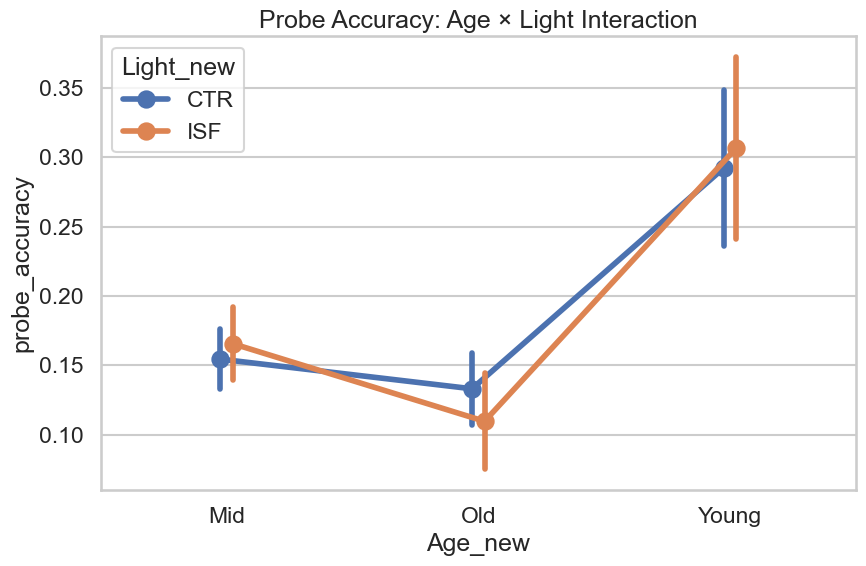

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9,6))

sns.pointplot(
    data=d,
    x="Age_new",
    y="probe_accuracy",
    hue="Light_new",
    errorbar="se",
    dodge=True,
    ax=ax
)

ax.set_title("Probe Accuracy: Age × Light Interaction")
plt.tight_layout()
plt.show()
